In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_ROOT = "results"
CRED_MODES = {
    "discrete_credibility": "Discrete",
    "normally_distributed_credibility": "Normal"
}

records = []

for seed in os.listdir(RESULTS_ROOT):
    seed_path = os.path.join(RESULTS_ROOT, seed)
    if not os.path.isdir(seed_path): continue
    
    for cm_dir, cm_label in CRED_MODES.items():
        mode_path = os.path.join(seed_path, cm_dir)
        if not os.path.isdir(mode_path): continue
        
        for file in os.listdir(mode_path):
            if not file.endswith("_metrics.csv"): continue
            
            # Extract belief type from filename
            belief_type = int(file.split("_")[0].replace("type", ""))
            csv_path = os.path.join(mode_path, file)
            
            print(f"Loading: {csv_path}")
            df = pd.read_csv(csv_path)
            df["belief_type"] = belief_type
            df["cred_mode"] = cm_label
            df["seed"] = seed
            
            records.append(df)

full_df = pd.concat(records, ignore_index=True)
print("\nLoaded results:", full_df.shape)


Loading: results\fifth_seed\discrete_credibility\type1_curated_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type1_echo_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type1_mixed_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type2_curated_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type2_echo_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type2_mixed_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type3_curated_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type3_echo_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type3_mixed_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type4_curated_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type4_echo_metrics.csv
Loading: results\fifth_seed\discrete_credibility\type4_mixed_metrics.csv
Loading: results\fifth_seed\normally_distributed_credibility\type1_curated_metrics.csv
Loading: results\fifth_seed\norma

In [4]:
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.2)

C:\Users\13363\AppData\Local\Temp\ipykernel_700\2010124450.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(
C:\Users\13363\AppData\Local\Temp\ipykernel_700\2010124450.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(
C:\Users\13363\AppData\Local\Temp\ipykernel_700\2010124450.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(
C:\Users\13363\AppData\Local\Temp\ipykernel_700\2010124450.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(


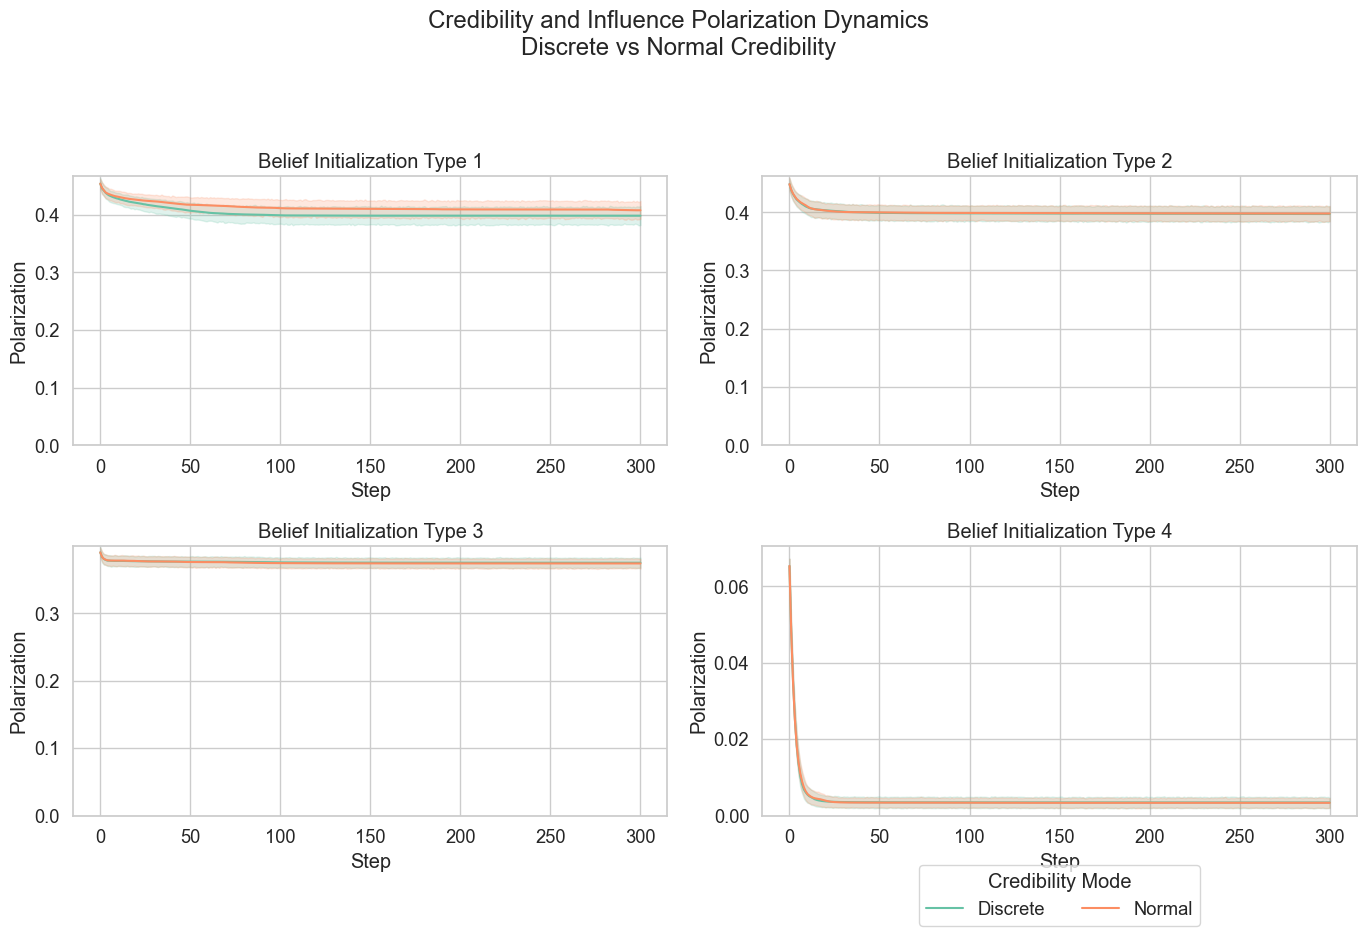

In [ ]:
plt.figure(figsize=(14,10))

axes = []
for i, btype in enumerate(sorted(full_df.belief_type.unique()), start=1):
    ax = plt.subplot(2,2,i)
    axes.append(ax)
    
    sub = full_df[full_df.belief_type == btype]
    
    sns.lineplot(
        data=sub, x="step", y="polarization_var",
        hue="cred_mode", ci=68, palette="Set2", ax=ax
    )
    
    ax.set_title(f"Belief Initialization Type {btype}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Polarization")
    ax.set_ylim(0, None)

# Remove per-subplot legends
for ax in axes:
    ax.get_legend().remove()

# Shared legend below plots
handles, labels = axes[0].get_legend_handles_labels()
plt.legend(
    handles, labels,
    title="Credibility Mode",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True
)

plt.suptitle("Credibility and Influence Polarization Dynamics\nDiscrete vs Normal Credibility", y=1.03)

plt.tight_layout(rect=(0, 0.08, 1, 0.98))

plt.savefig("polarization_trajectories_labeled.png", dpi=300, bbox_inches="tight")
plt.show()
